# Learned vs gated sign head — 3×3 field-grid heatmaps

Doubled semion, 2×3 honeycomb (N = 27), `hx ∈ {0.4, 0.8, 1.2} × hz ∈ {0, 0.2, 0.4}`; three arms, identical trunk / optimizer / sampler / 350-step budget:

| arm | ψ | learned sign? |
|---|---|---|
| **M** | `A(σ)·tanh(MLP(ε, x))`, positive-ansatz init | yes, from the energy alone |
| **M-pre** | same, MLP pre-fit to the exact ED signs at the same point | warm-started |
| **T** | `a_s·A_triv(σ) + s_head(σ)·A_top(σ)`, deterministic head (MWPM + closed-form loop sign) | no |

Metrics: relative energy error vs exact `E0`, and `1−F`, `F = |⟨ψ_ED|ψ_NQS⟩|²` (full 2^N enumeration). Each `1−F` cell carries the arm's representability ceiling (`T_gate` for T; 0 for M / M-pre, whose input `(ε, x)` determines σ). Data: `python scripts/signbench_summary.py --Lx 2 --Ly 3 --out results/diagnostics/signbench_2d.json`; a 3D row appears when the peer repo's `signbench_3d.json` exists.

## The three architectures

All three share the **positive Combo trunk** `A(σ) > 0` (Block-1 local CNN → Wilson vertex tokens `Q_v` → all-to-all invariant CNN → exp), the Phase-3 recipe (minSR, lr 0.01, diag-shift 6e-5, 8192 samples, 350 steps, seed 0) and the same **deterministic feature map** `σ → (ε, x)`: read the `Q_v` syndrome, pair the defects with MWPM to get the recovery `ε`, repair `r = σ ⊕ ε` (closed-loop sector), and solve `x = G⁻¹ r` over GF(2) — `x_p ∈ {0,1}` says which hexagons were flipped from all-up to reach `r`. `(ε, x)` determines `σ` exactly, so every arm sees the full configuration in decoder coordinates.

| | **M** (`cnnqM`) | **M-pre** (`cnnqMp`) | **T** (`cnnqT`) |
|---|---|---|---|
| wavefunction | `ψ = A(σ) · tanh(m_θ(ε, x))` | same as M | `ψ = a_{s(σ)} · A_triv(σ) + s(σ) · A_top(σ)` |
| sign source | MLP `m_θ`: 33 → 64 → 64 → 1 (tanh), sign = sign(m) | same MLP | closed form: `s(σ) = (−1)^{poly(x)}`, the Levin–Gu cubic `Σx_p + Σ_{edge-pairs} x_p x_q + Σ_{vertex-triples} x_p x_q x_r` (= loop parity of `r`) |
| trainable sign? | yes — learned from the energy alone | yes — warm-started | **no** — the head is fixed; the two positive trunks and the two scalars `a₊, a₋` (one per head sector, init +0.05) decide per configuration how much of the head-signed branch vs the plain positive branch to use |
| init | positive ansatz (`tanh(1)` everywhere: last layer zero-kernel, bias +1) | MLP pre-fit to the exact ED signs at the same point (`\|ψ_ED\|²`-weighted BCE, best of ≤3000 epochs) | ≈ head-only arm (`a = 0.05`) |
| params (2×3) | 25,418 | 25,418 | 38,036 (two trunks) |
| ceiling | 0 | 0 | `T_gate` = ED weight the two positive trunks cannot re-sign, min over the two head sectors |

Reading guide: M tests whether VMC can *discover* the sign; M-pre tests whether it can *keep* a correct sign it was handed; T tests whether a deterministic sign prior plus a learned per-configuration gate suffices — including past the crossover (`h_x ≈ 1.1`), where the head alone is wrong and `a < 0` lets the trivial branch take over.

In [1]:
import json, os, pathlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

os.chdir(next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / 'results').is_dir()))
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
LABEL = {'cnnqM': 'M', 'cnnqMp': 'M-pre', 'cnnqT': 'T', 'cnnqTp': 'T+'}

panels = [('2D doubled semion 2×3', json.load(open('results/diagnostics/signbench_2d.json')))]
if os.path.exists('results/diagnostics/signbench_3d.json'):
    d3 = json.load(open('results/diagnostics/signbench_3d.json'))
    d3['points'] = [[hx, hz] for hx in (0.2, 0.5, 0.8) for hz in (0, 0.2, 0.4)]   # planned 3D grid (plan Sec 2)
    panels.append(('3D fermionic TC 2×2×3', d3))
print({name: f"{sum(not r['missing'] for r in d['records'])}/{len(d['records'])} runs" for name, d in panels})

{'2D doubled semion 2×3': '30/36 runs', '3D fermionic TC 2×2×3': '64/64 runs'}


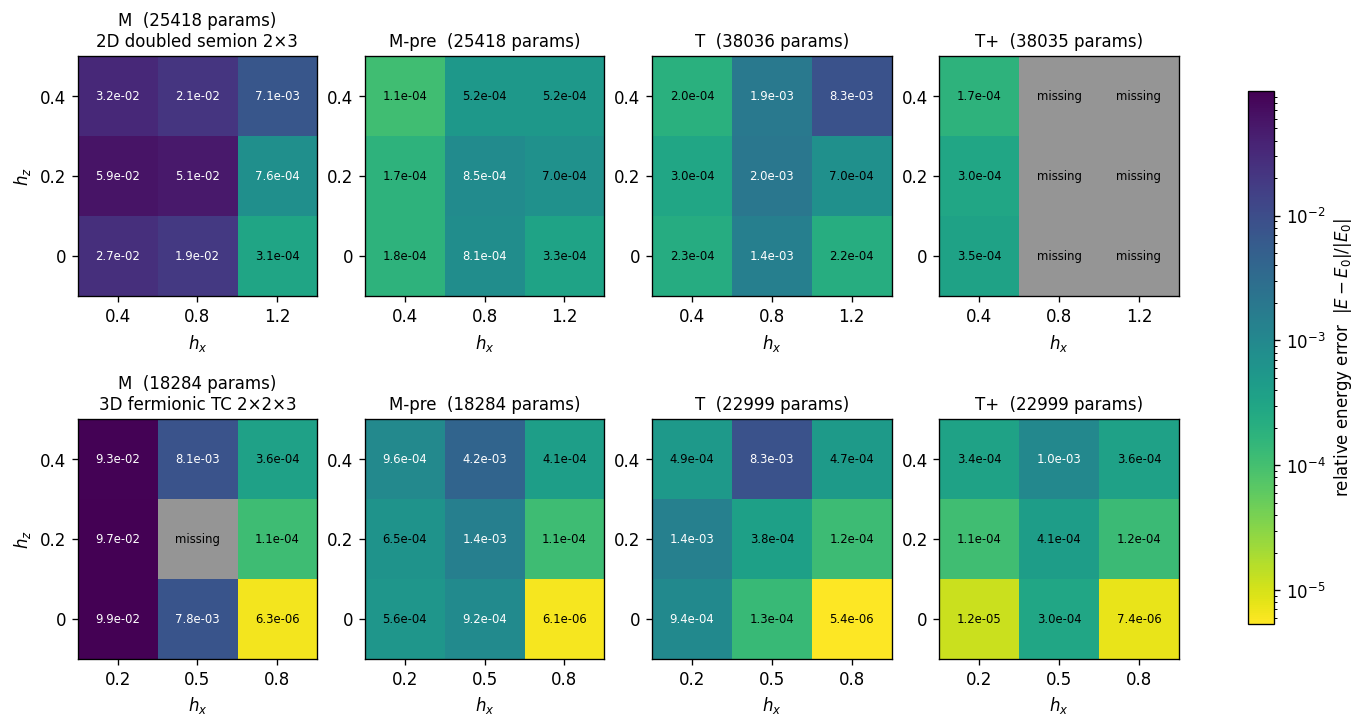

In [2]:
def grid(d, arm, key):
    '''array of `key` over the planned grid d['points'] (rows hz, cols hx; seed 0), NaN where missing.'''
    records = d['records']
    hx = sorted({p[0] for p in d['points']}); hz = sorted({p[1] for p in d['points']})
    g = np.full((len(hz), len(hx)), np.nan)
    for r in records:
        if r['arm'] == arm and r.get('seed', 0) == 0 and r.get(key) is not None:
            if r['hz'] in hz and r['hx'] in hx:
                g[hz.index(r['hz']), hx.index(r['hx'])] = r[key]
    return g, hx, hz


def heatmaps(key, title, ceiling=False):
    '''rows = panels (2D / 3D), cols = arms; one shared log colour scale.'''
    vals = [v for _, d in panels for a in d['arms'] for v in grid(d, a, key)[0].ravel() if v > 0]
    if not vals:
        return print(f'{key}: no data yet (fidelity jobs still queued)')
    norm = LogNorm(min(vals), max(vals))
    ncol = max(len(d['arms']) for _, d in panels)
    fig, axes = plt.subplots(len(panels), ncol, figsize=(3.7 * ncol, 3.6 * len(panels)), squeeze=False)
    for ax in axes.ravel(): ax.set_visible(False)
    for row, (name, d) in enumerate(panels):
        for col, arm in enumerate(d['arms']):
            ax, (g, hx, hz) = axes[row, col], grid(d, arm, key); ax.set_visible(True)
            im = ax.imshow(np.where(g > 0, g, norm.vmin), norm=norm, cmap='viridis_r', origin='lower')
            ax.imshow(np.where(np.isnan(g), 0.5, np.nan), cmap='Greys', vmin=0, vmax=1, origin='lower')
            rec = {(r['hx'], r['hz']): r for r in d['records'] if r['arm'] == arm and r.get('seed', 0) == 0}
            for i, z in enumerate(hz):
                for j, x in enumerate(hx):
                    v, r = g[i, j], rec.get((x, z), {})
                    txt = 'missing' if np.isnan(v) else f'{v:.1e}'
                    if ceiling and not np.isnan(v) and r.get('ceiling') is not None:
                        used = r.get('ceiling_used')      # ceiling of the sector family T actually trained in
                        txt += f"\nceil {r['ceiling']:.0e}" + (f"\nused {used:.0e}" if used not in (None, r['ceiling']) else '')
                    dark = not np.isnan(v) and norm(max(v, norm.vmin)) > 0.5
                    ax.text(j, i, txt, ha='center', va='center', fontsize=7, color='w' if dark else 'k')
            n = next((r['n_params'] for r in d['records'] if r['arm'] == arm and r.get('n_params')), '?')
            ax.set_title(f"{LABEL.get(arm, arm)}  ({n} params)" + (f"\n{name}" if col == 0 else ''), fontsize=10)
            ax.set_xticks(range(len(hx)), [f'{x:g}' for x in hx]); ax.set_yticks(range(len(hz)), [f'{z:g}' for z in hz])
            ax.set_xlabel('$h_x$'); ax.set_ylabel('$h_z$' if col == 0 else '')
    fig.colorbar(im, ax=axes, label=title, shrink=0.8)
    os.makedirs('figures/signbench', exist_ok=True)
    fig.savefig(f'figures/signbench/{key}.png', dpi=200, bbox_inches='tight')
    return fig

heatmaps('rel_err', 'relative energy error  $|E-E_0|/|E_0|$');

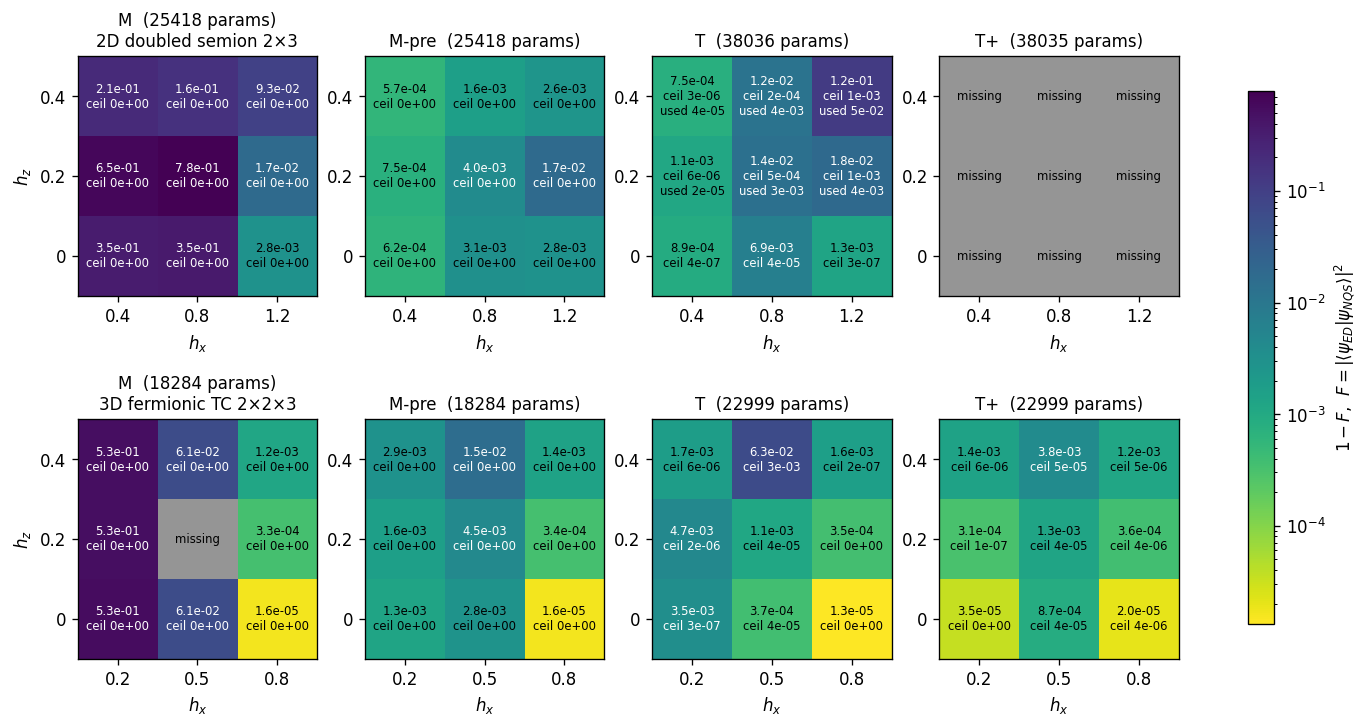

In [3]:
heatmaps('one_minus_F', r'$1-F$,  $F=|\langle\psi_{ED}|\psi_{NQS}\rangle|^2$', ceiling=True);

In [4]:
# Arm T's trained sector mix [a+, a-] and M-pre's warm-start sign fidelity, per cell.
for r in panels[0][1]['records']:
    if r['arm'] == 'cnnqT' and r.get('mix') is not None:
        print(f"T     ({r['hx']:g},{r['hz']:g})  mix = {np.round(r['mix'], 2)}  family = {r.get('family')}  ceiling used = {r.get('ceiling_used')}")
    if r['arm'] == 'cnnqMp' and r.get('warm_1mFs') is not None:
        print(f"M-pre ({r['hx']:g},{r['hz']:g})  warm-start 1-F_s = {r['warm_1mFs']:.1e}")

M-pre (0.4,0)  warm-start 1-F_s = 9.8e-06
T     (0.4,0)  mix = [-0.99 -0.25]  family = minus-pinned  ceiling used = 4.1962616874934975e-07
M-pre (0.4,0.2)  warm-start 1-F_s = 9.9e-06
T     (0.4,0.2)  mix = [-1.04 -0.12]  family = minus-pinned  ceiling used = 1.998568935140679e-05
M-pre (0.4,0.4)  warm-start 1-F_s = 9.6e-06
T     (0.4,0.4)  mix = [-1.34 -0.19]  family = minus-pinned  ceiling used = 4.085472308488032e-05
M-pre (0.8,0)  warm-start 1-F_s = 3.3e-05
T     (0.8,0)  mix = [-0.63 -0.43]  family = minus-pinned  ceiling used = 4.192001877629453e-05
M-pre (0.8,0.2)  warm-start 1-F_s = 2.4e-05
T     (0.8,0.2)  mix = [-0.56 -0.63]  family = minus-pinned  ceiling used = 0.00271653022146736
M-pre (0.8,0.4)  warm-start 1-F_s = 3.6e-05
T     (0.8,0.4)  mix = [-0.71 -0.54]  family = minus-pinned  ceiling used = 0.003702792062321599
M-pre (1.2,0)  warm-start 1-F_s = 2.6e-04
T     (1.2,0)  mix = [-1.62 -1.6 ]  family = minus-pinned  ceiling used = 3.405311207741276e-07
M-pre (1.2,0.2)  war